In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

##1.Load Dataset

In [ ]:



df=pd.read_csv("D:\do_an_mon_hoc\he_quyet_dinh\dataset (1).csv")

In [ ]:
df.shape

(4424, 35)

In [ ]:
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [ ]:
df.tail()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
4419,1,1,6,15,1,1,1,1,1,6,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
4420,1,1,2,15,1,1,19,1,1,10,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
4421,1,1,1,12,1,1,1,22,27,10,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
4422,1,1,1,9,1,1,1,22,27,8,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate
4423,1,5,1,15,1,1,9,23,27,6,...,0,6,6,6,13.000000,0,12.7,3.7,-1.70,Graduate


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's occupation                      

In [ ]:
df.describe()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,6.886980,1.727848,9.899186,0.890823,2.531420,1.254521,12.322107,16.455244,7.317812,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,5.298964,1.313793,4.331792,0.311897,3.963707,1.748447,9.026251,11.044800,3.997828,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,6.000000,1.000000,1.000000,1.000000,2.000000,3.000000,5.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,8.000000,1.000000,10.000000,1.000000,1.000000,1.000000,13.000000,14.000000,6.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,12.000000,2.000000,13.000000,1.000000,1.000000,1.000000,22.000000,27.000000,10.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,18.000000,9.000000,17.000000,1.000000,17.000000,21.000000,29.000000,34.000000,32.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [ ]:
df.columns

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Displaced',
       'Educational special needs', 'Debtor', 'Tuition fees up to date',
       'Gender', 'Scholarship holder', 'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)',
       'Curricular units 2nd sem (without evaluations)

## 2.Data qualities

###2.1 Mising value

In [ ]:
missing=df.isna().sum()
missing_percent=(
    missing/len(df)*100
).sort_values(ascending=False)

pd.DataFrame({
    "missing":missing,
    "percetage":missing_percent
})

,missing,percetage
Marital status,0,0.0
Application mode,0,0.0
Application order,0,0.0
Course,0,0.0
Daytime/evening attendance,0,0.0
Previous qualification,0,0.0
Nacionality,0,0.0
Mother's qualification,0,0.0
Father's qualification,0,0.0
Mother's occupation,0,0.0


###2.2 Duplicate

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df[df.duplicated()]

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target


#EDA

## Numerical

In [ ]:
df["Target"].value_counts()

,count
Target,
Graduate,2209
Dropout,1421
Enrolled,794


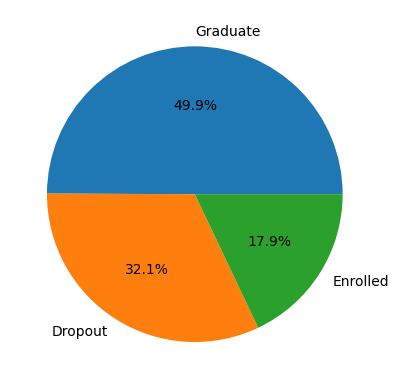

In [ ]:

X=df["Target"].value_counts()
labels=X.index
sizes=X.values
plt.pie(sizes, labels=labels,autopct='%1.1f%%')
plt.show()

In [ ]:
data_num=df.select_dtypes(include="float64")
data_num

,Curricular units 1st sem (grade),Curricular units 2nd sem (grade),Unemployment rate,Inflation rate,GDP
0,0.000000,0.000000,10.8,1.4,1.74
1,14.000000,13.666667,13.9,-0.3,0.79
2,0.000000,0.000000,10.8,1.4,1.74
3,13.428571,12.400000,9.4,-0.8,-3.12
4,12.333333,13.000000,13.9,-0.3,0.79
...,...,...,...,...,...
4419,13.600000,12.666667,15.5,2.8,-4.06
4420,12.000000,11.000000,11.1,0.6,2.02
4421,14.912500,13.500000,13.9,-0.3,0.79
4422,13.800000,12.000000,9.4,-0.8,-3.12


/tmp/ipykernel_16270/3574311417.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[i])


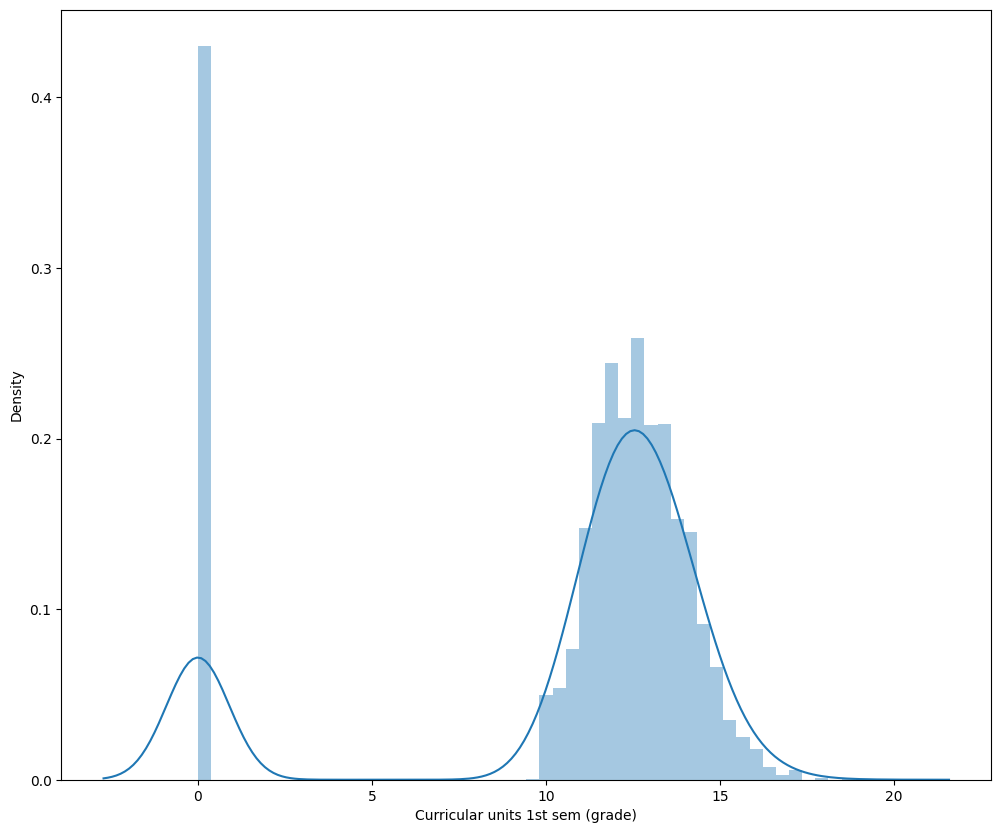

/tmp/ipykernel_16270/3574311417.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[i])


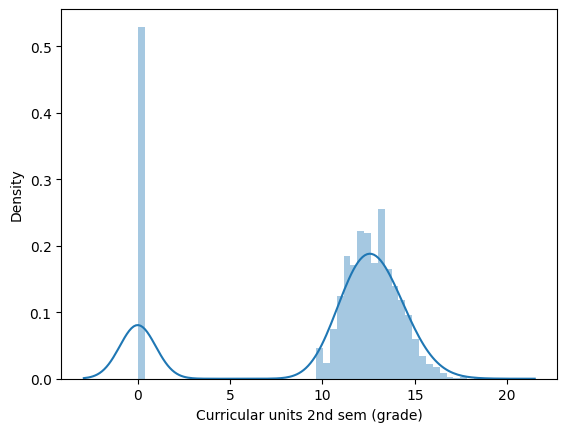

/tmp/ipykernel_16270/3574311417.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[i])


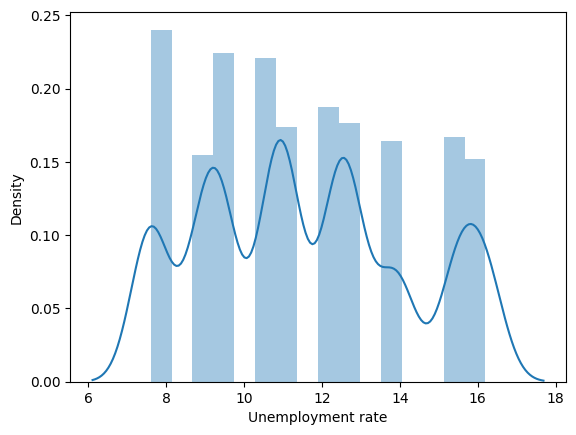

/tmp/ipykernel_16270/3574311417.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[i])


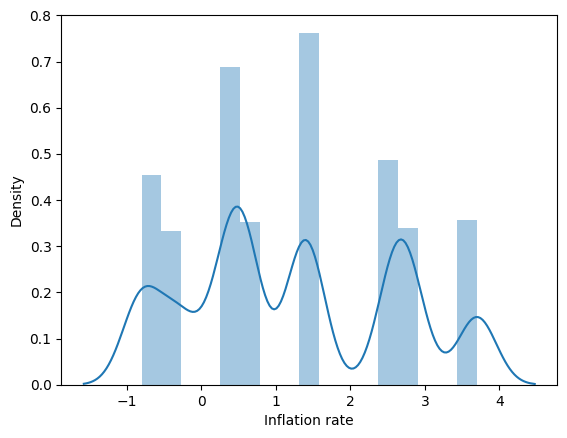

/tmp/ipykernel_16270/3574311417.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[i])


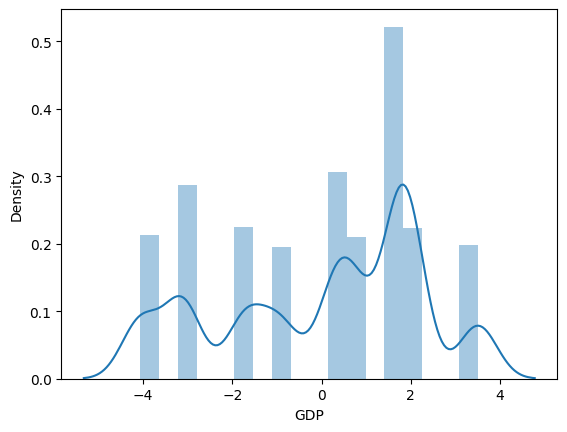

In [ ]:
import seaborn as sns

plt.figure(figsize=(12, 10))

for i in data_num.columns:
    sns.distplot(df[i])
    plt.show()

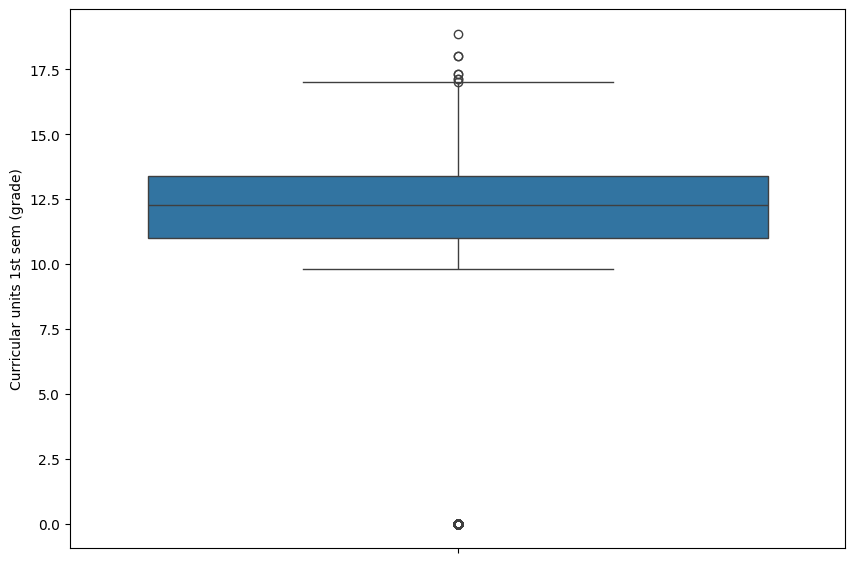

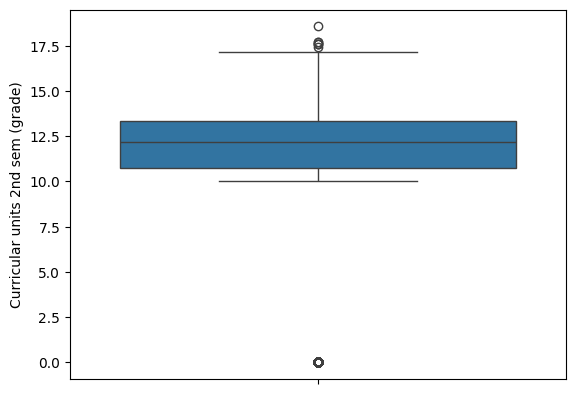

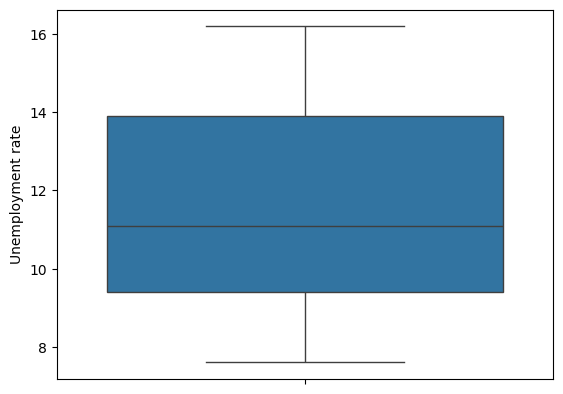

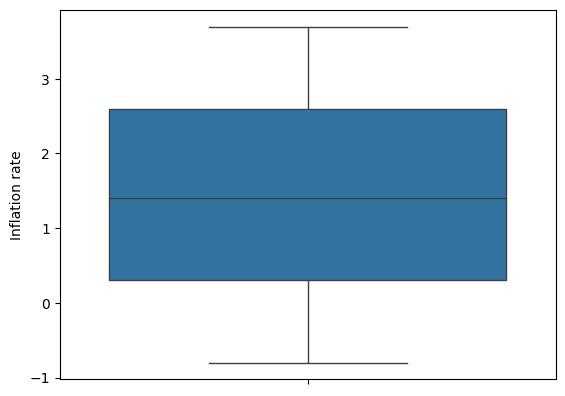

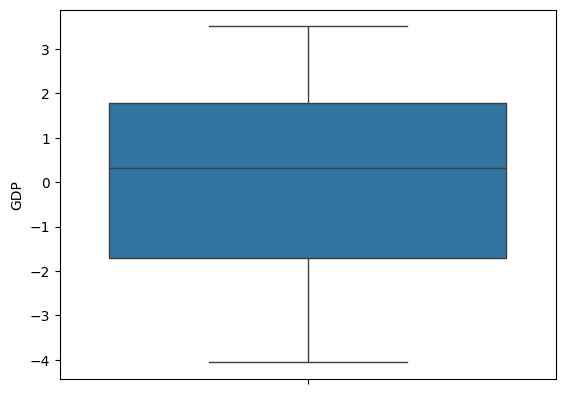

In [ ]:
#boxplot
plt.figure(figsize=(10,7))

for i in data_num.columns:
    sns.boxplot(df[i])
    plt.show()

Từ biểu đồ ta thấy hầu hết các biểu đồ đều có giá trị ngoại lai


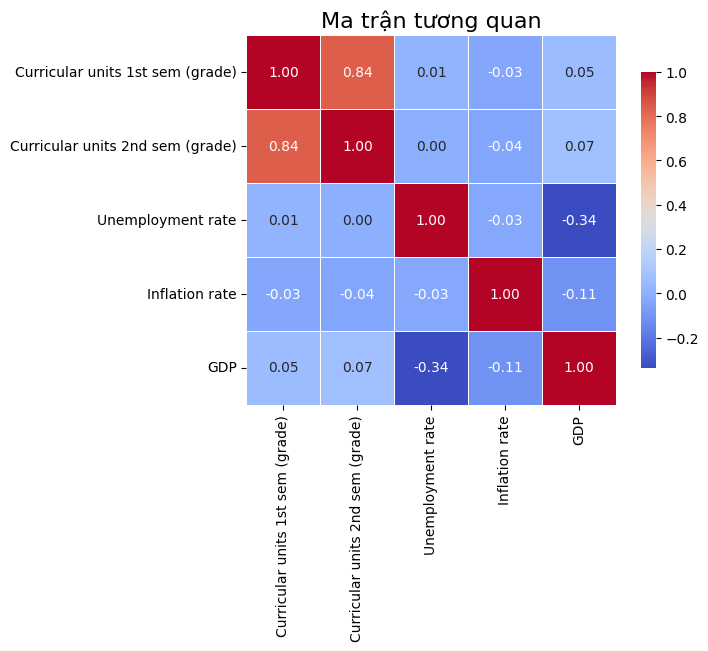

In [ ]:
corr_matrix=data_num.corr()
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            linewidths=0.5,
            square=True,
            cbar_kws={"shrink": 0.8})

plt.title('Ma trận tương quan', fontsize=16)
plt.show()

## Catagorical

In [ ]:
cat_cols = df._get_numeric_data().columns
cat_cols

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Displaced',
       'Educational special needs', 'Debtor', 'Tuition fees up to date',
       'Gender', 'Scholarship holder', 'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)',
       'Curricular units 2nd sem (without evaluations)

In [ ]:
cate_cols=list(set(cat_cols)-set(data_num))
cate_cols

['Curricular units 2nd sem (enrolled)',
 'Curricular units 1st sem (evaluations)',
 'Gender',
 'Nacionality',
 'Curricular units 1st sem (credited)',
 'Curricular units 2nd sem (evaluations)',
 'Educational special needs',
 'Curricular units 2nd sem (credited)',
 "Father's qualification",
 'International',
 'Marital status',
 'Curricular units 1st sem (without evaluations)',
 'Curricular units 2nd sem (without evaluations)',
 'Scholarship holder',
 'Debtor',
 'Age at enrollment',
 "Mother's qualification",
 'Daytime/evening attendance',
 'Tuition fees up to date',
 'Application mode',
 'Curricular units 2nd sem (approved)',
 'Curricular units 1st sem (approved)',
 'Application order',
 'Displaced',
 "Father's occupation",
 "Mother's occupation",
 'Previous qualification',
 'Curricular units 1st sem (enrolled)',
 'Course']

In [ ]:
len(cate_cols)

29

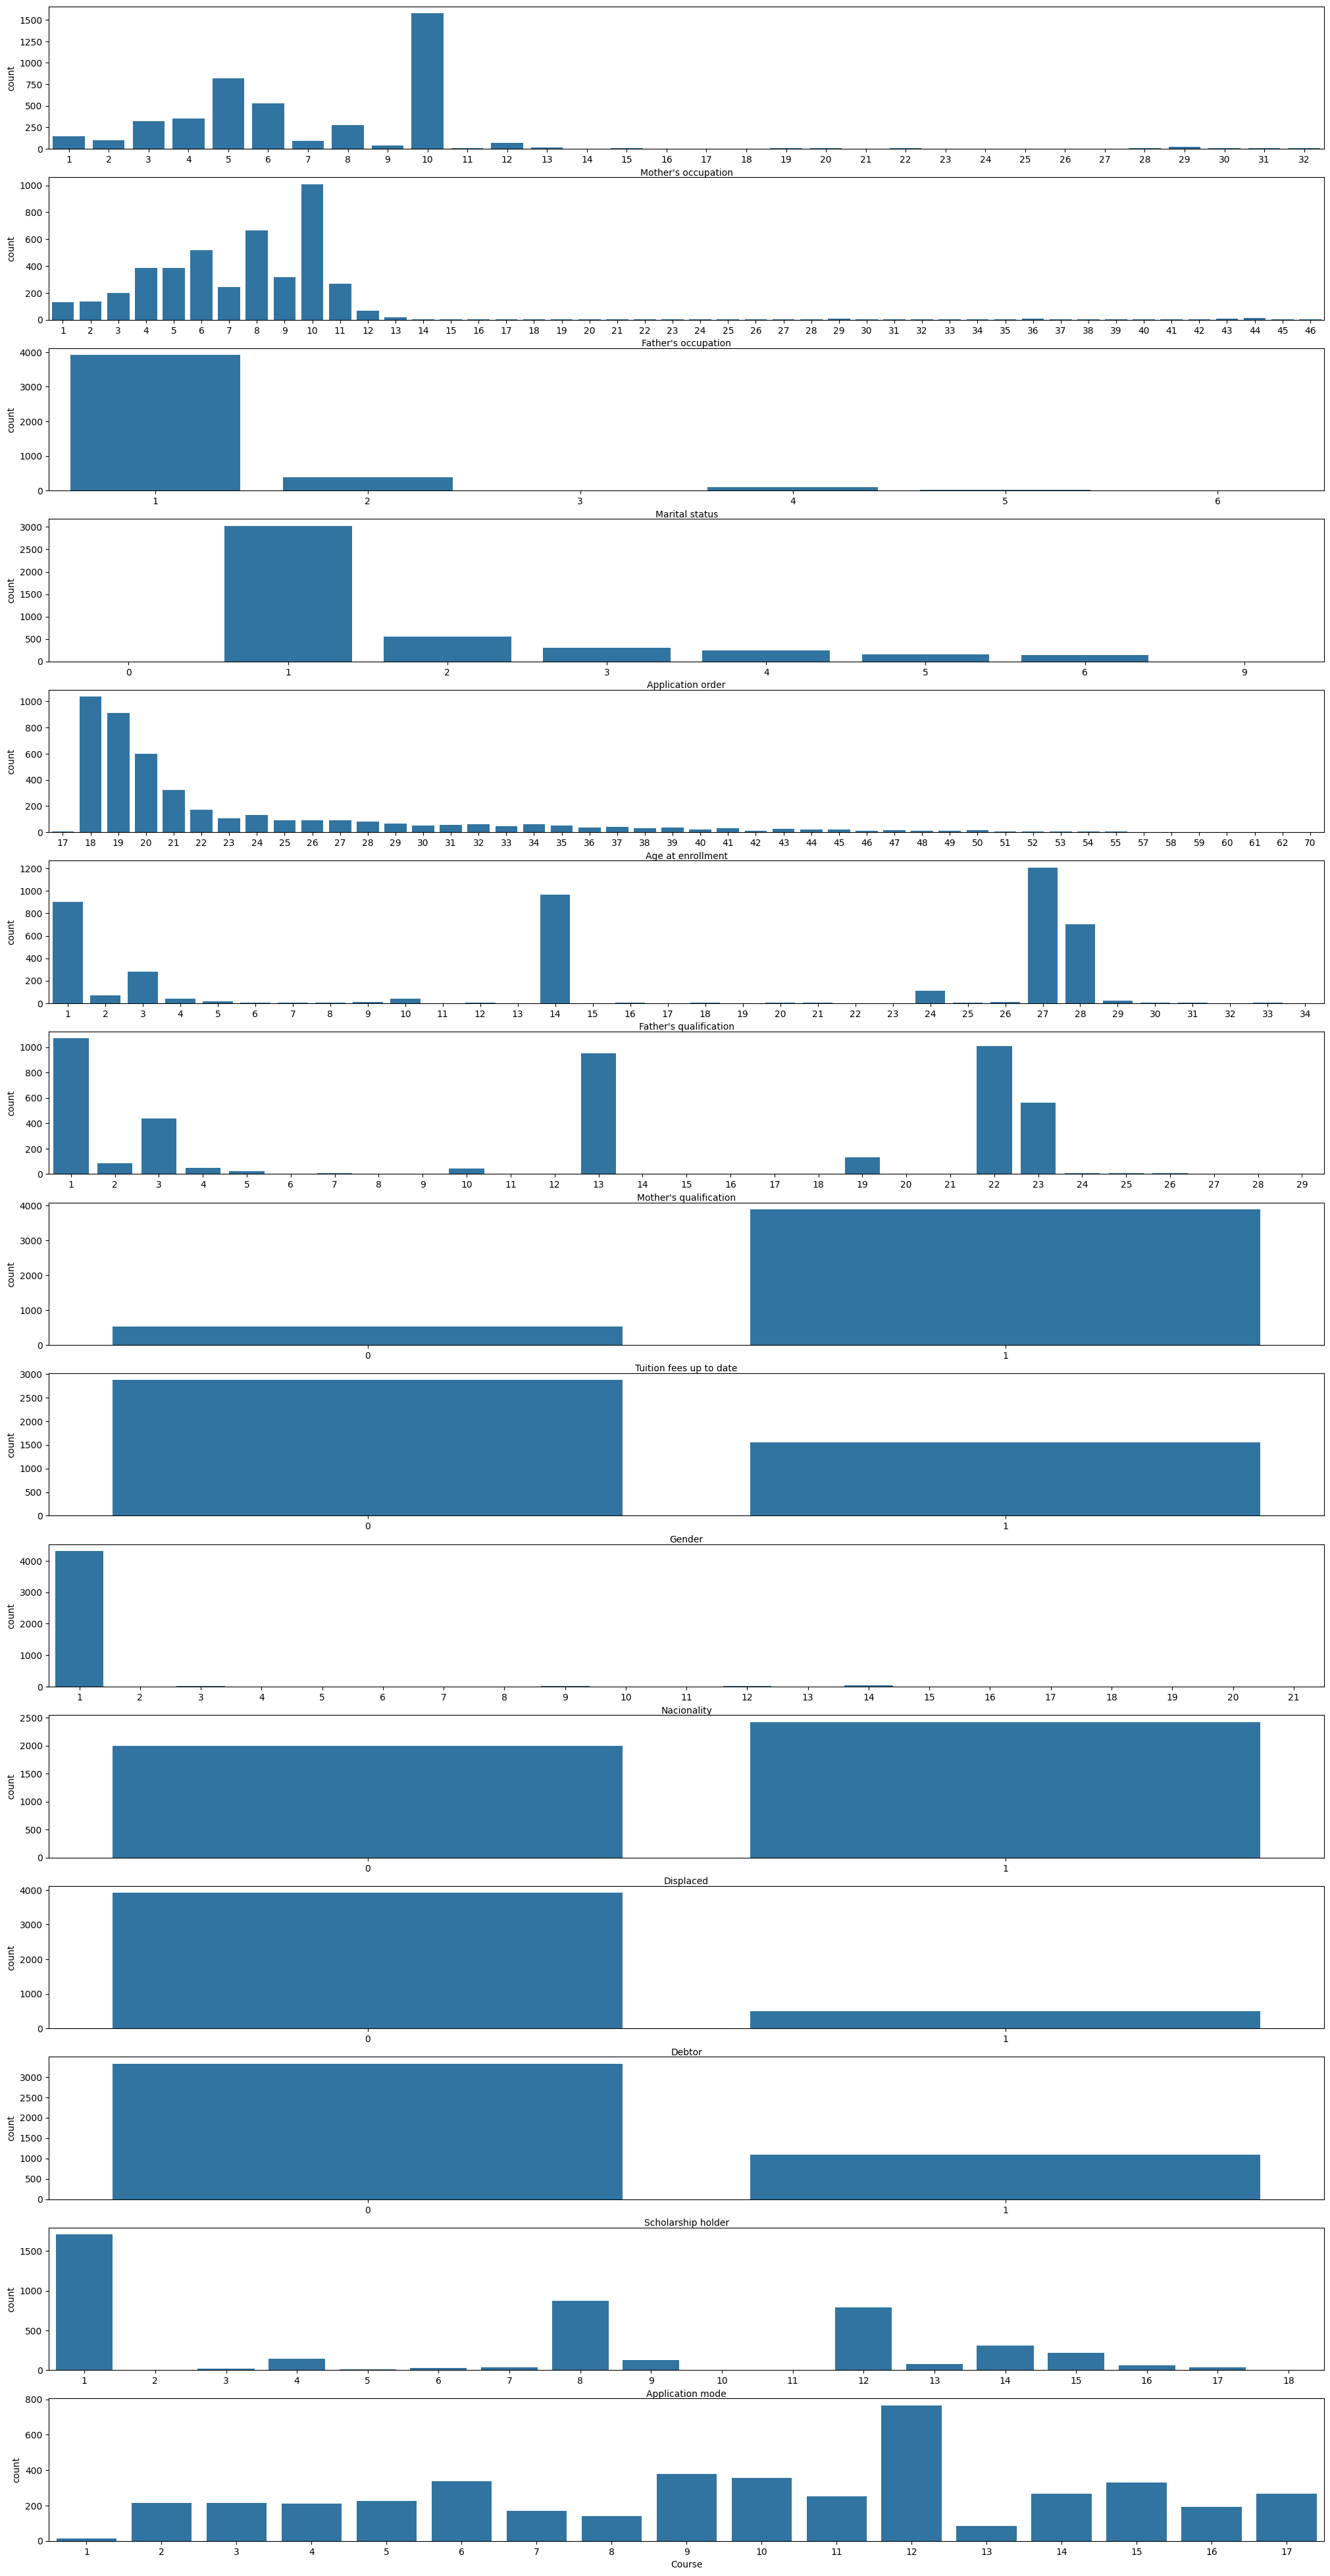

In [ ]:
fig, ax = plt.subplots(nrows=15, ncols=1, figsize=(25, 50))

cols_ = ["Mother's occupation",
 "Father's occupation",
 'Marital status',
 'Application order',
 'Age at enrollment',
 "Father's qualification",
 "Mother's qualification",
 'Tuition fees up to date',
 'Gender',
  "Nacionality",
 'Displaced',
 'Debtor',
 "Scholarship holder",
 'Application mode',
 'Course']

for ind, col in enumerate(cols_):
    sns.countplot(x=col, data=df, ax=ax[ind])

Đa số các bà mẹ là lao động phổ thông (không có tay nghề), tiếp theo là nhân viên hành chính, nhân viên an toàn lao động và nhân viên bán hàng.

Đa số các ông bố là lao động phổ thông (không có tay nghề), tiếp theo là công nhân có tay nghề trong ngành công nghiệp, nhân viên an toàn lao động, nhân viên bảo vệ và nhân viên bán hàng.

Hơn 90% sinh viên trong tập dữ liệu đang độc thân.

Đa số sinh viên nhập học ở độ tuổi 18, 19 và 20.

Đa số phụ huynh có trình độ học vấn ở mức cơ bản, từ lớp 5 đến lớp 12.

Hơn 90% sinh viên đóng học phí đúng hạn.

Trong nhóm sinh viên này, hơn 60% là nữ.

Gần như tất cả sinh viên trong nhóm này đều là người Bồ Đào Nha.

Đa số sinh viên trong nhóm này không phải là người nhận học bổng.

Đa số sinh viên đăng ký theo đợt tuyển sinh đợt 1, tiếp theo là đợt 2.

Đa số sinh viên theo học ngành Điều dưỡng (Nursing), tiếp theo là các ngành Quản trị, Dịch vụ xã hội, Báo chí và Truyền thông.

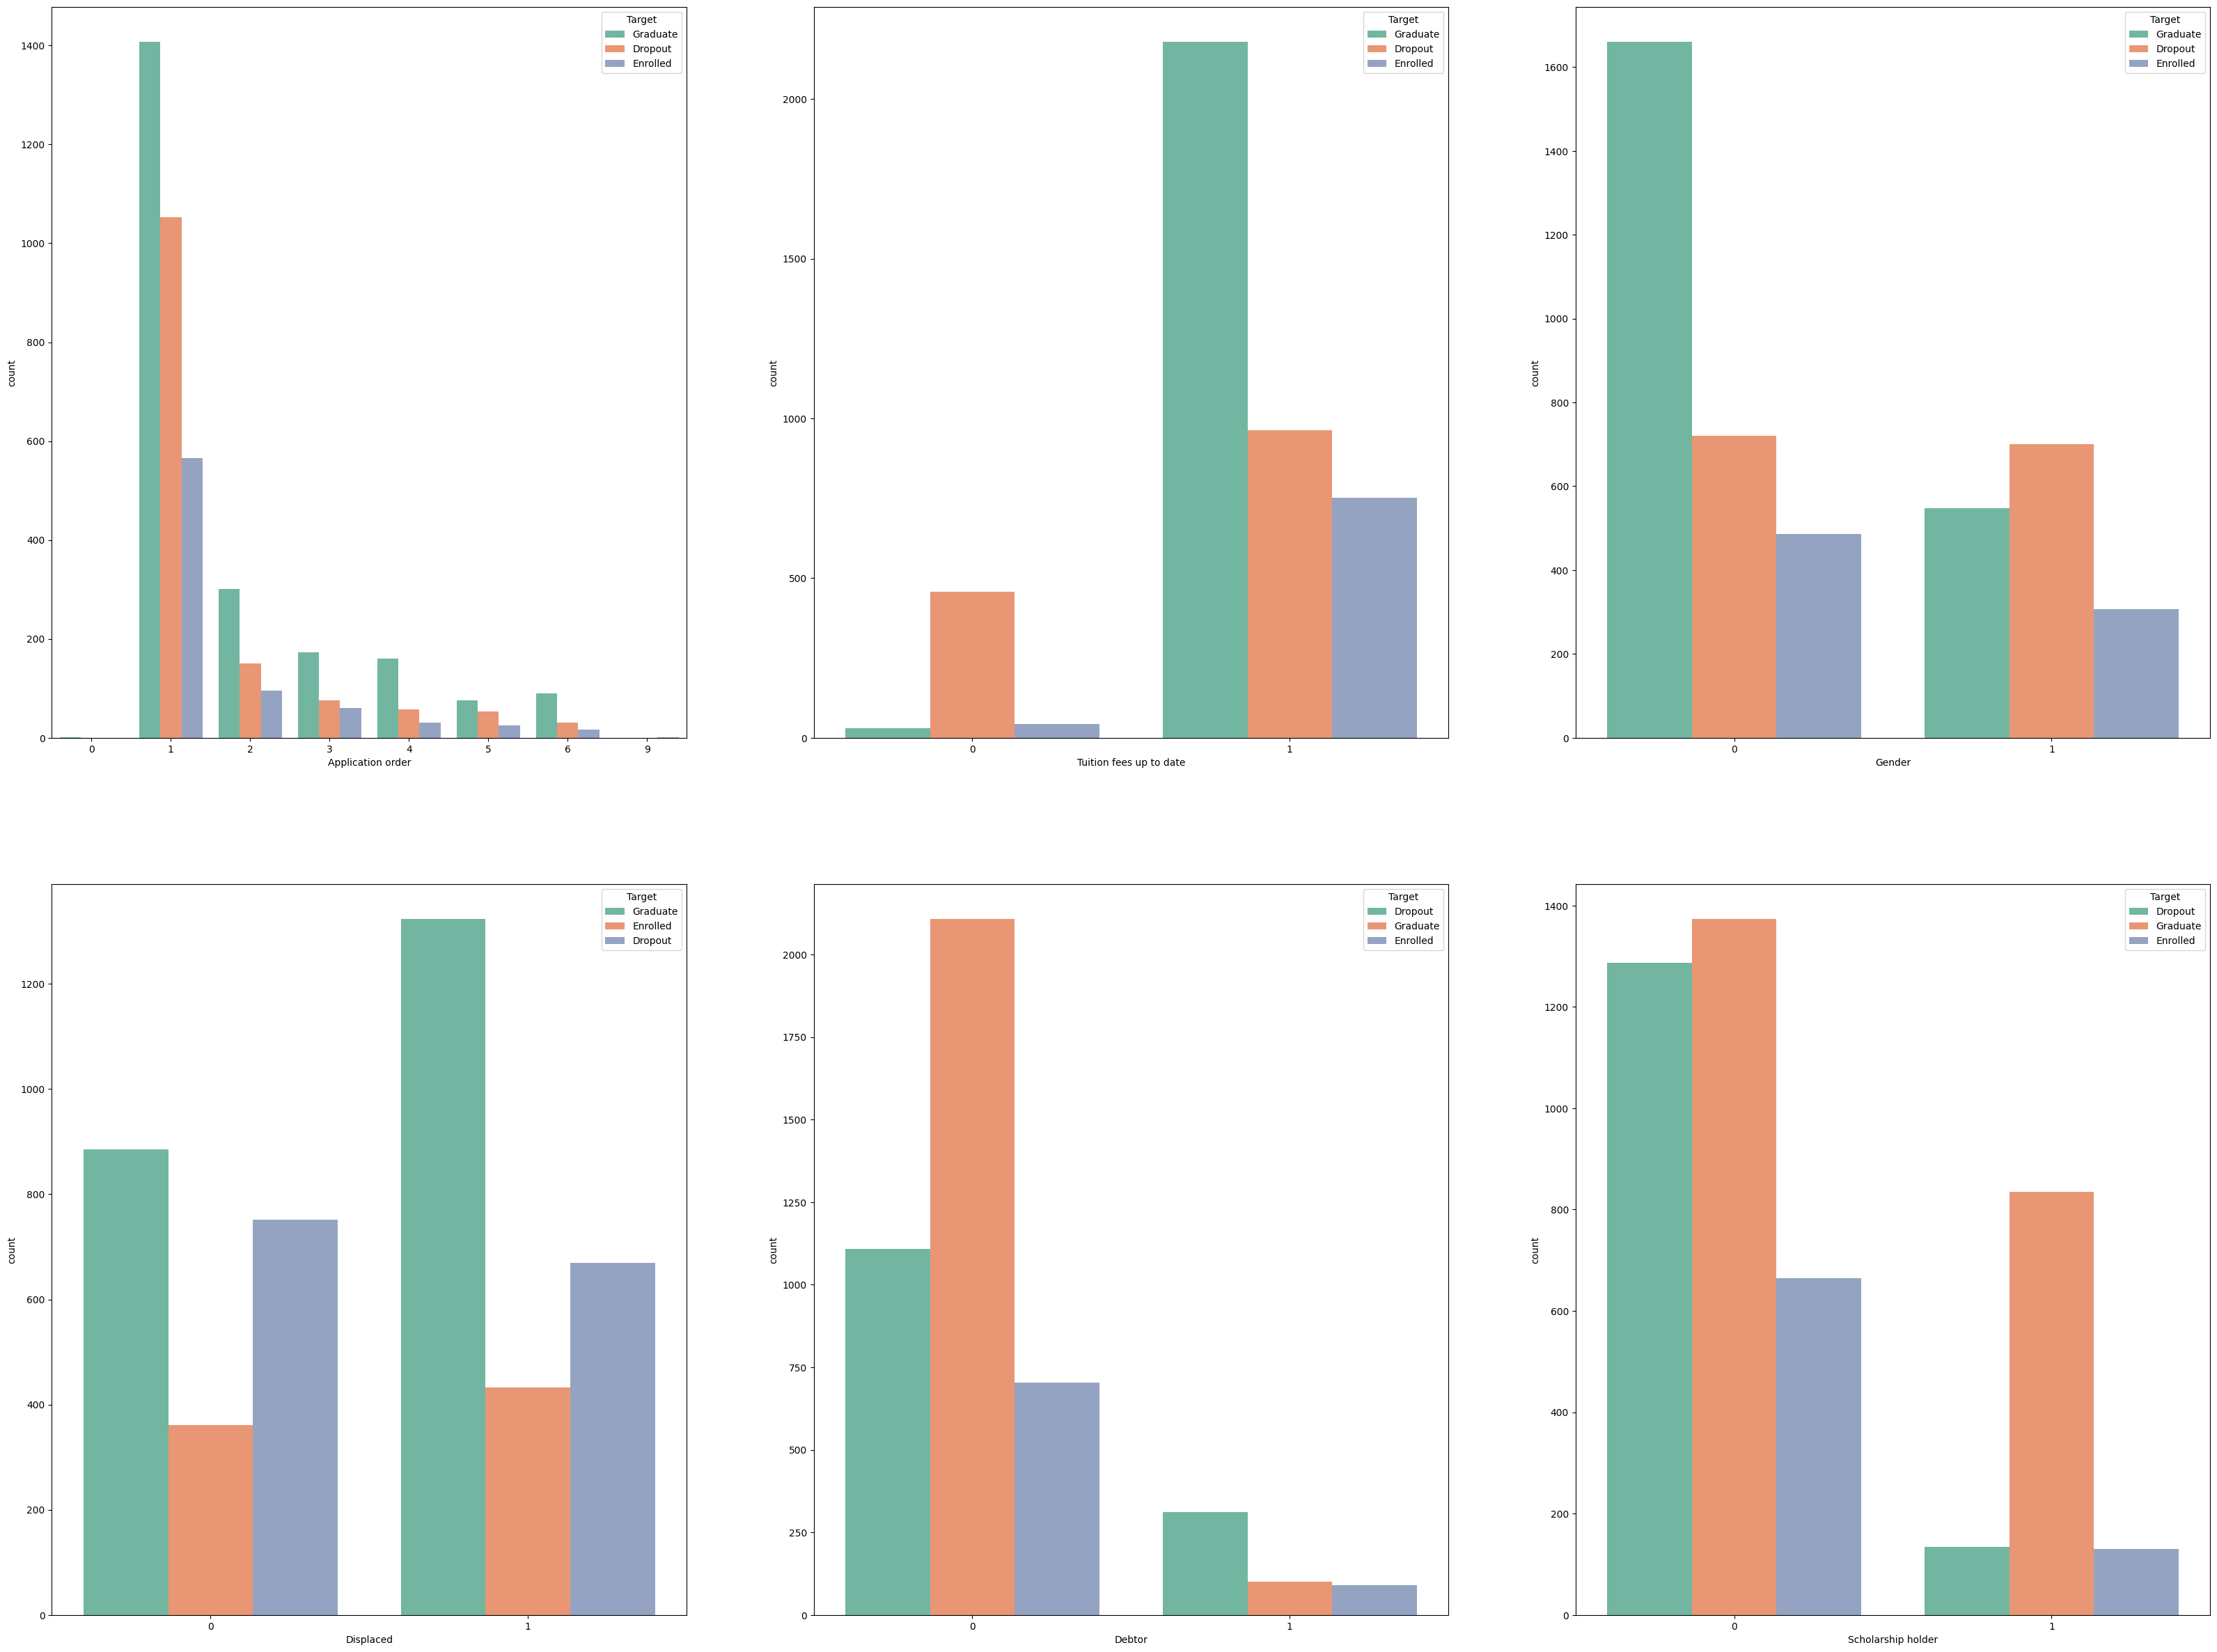

In [ ]:
fig, ax = plt.subplots(2, 3, figsize=(40, 30))

sns.countplot(x='Application order', hue='Target', data=df, palette='Set2', ax=ax[0][0])
sns.countplot(x='Tuition fees up to date', hue='Target', data=df, palette='Set2', ax=ax[0][1])
sns.countplot(x='Gender', hue='Target', data=df, palette='Set2', ax=ax[0][2])
sns.countplot(x='Displaced', hue='Target', data=df, palette='Set2', ax=ax[1][0])
sns.countplot(x='Debtor', hue='Target', data=df, palette='Set2', ax=ax[1][1])
sns.countplot(x='Scholarship holder', hue='Target', data=df, palette='Set2', ax=ax[1][2])


plt.show()

- Những sinh viên không đóng học phí đúng hạn có khả năng bỏ học cao
- Phần lớn sinh viên nam có khả năng bỏ học cao
- Sinh viên đang nợ học phí có khả năng bỏ học cao

# Processing

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df['Target'])

X = df.drop('Target', axis=1)

print(le.classes_)

['Dropout' 'Enrolled' 'Graduate']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print(f"Train:{len(X_train)}")
print(f"Test:{len(X_test)}")

Train:3539
Test:885


In [ ]:
numerical_cols = [
    'Age at enrollment',
    'Application order',

    'Curricular units 1st sem (credited)',
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 1st sem (without evaluations)',

    'Curricular units 2nd sem (credited)',
    'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 2nd sem (without evaluations)',

    'Unemployment rate',
    'Inflation rate',
    'GDP'
]
categorical_cols = [
    'Marital status',
    'Application mode',
    'Course',
    'Daytime/evening attendance',
    'Previous qualification',
    'Nacionality',
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    'Displaced',
    'Educational special needs',
    'Debtor',
    'Tuition fees up to date',
    'Gender',
    'Scholarship holder',
    'International'
]

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'),numerical_cols),
        ('num', 'passthrough', categorical_cols)
    ]
)

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)


X_test_processed = preprocessor.transform(X_test)

model = RandomForestClassifier(random_state=42)
model.fit(X_train_processed, y_train)

y_pred = model.predict(X_test_processed)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_
))

              precision    recall  f1-score   support

     Dropout       0.82      0.75      0.78       284
    Enrolled       0.66      0.31      0.43       159
    Graduate       0.76      0.94      0.84       442

    accuracy                           0.77       885
   macro avg       0.75      0.67      0.68       885
weighted avg       0.76      0.77      0.75       885



# DTree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train_processed, y_train)

y_pred_dt = dt_model.predict(X_test_processed)

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_dt))

print(classification_report(
    y_test,
    y_pred_dt,
    target_names=le.classes_
))

Accuracy: 0.6949152542372882
              precision    recall  f1-score   support

     Dropout       0.70      0.69      0.69       284
    Enrolled       0.41      0.38      0.40       159
    Graduate       0.78      0.81      0.80       442

    accuracy                           0.69       885
   macro avg       0.63      0.63      0.63       885
weighted avg       0.69      0.69      0.69       885



# XGBoot

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss"
)


xgb_model.fit(X_train_processed, y_train)


y_pred = xgb_model.predict(X_test_processed)


accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Dropout", "Enrolled", "Graduate"]
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7694915254237288

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.83      0.71      0.77       284
    Enrolled       0.53      0.45      0.49       159
    Graduate       0.81      0.92      0.86       442

    accuracy                           0.77       885
   macro avg       0.72      0.70      0.70       885
weighted avg       0.76      0.77      0.76       885


Confusion Matrix:
[[203  40  41]
 [ 30  72  57]
 [ 12  24 406]]
